#LIBRARY / DATA

In [ ]:
import numpy as np
import pandas as ps
import matplotlib.pyplot as plt
import seaborn as sns
sns.set

<function seaborn.rcmod.set(*args, **kwargs)>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set

<function seaborn.rcmod.set(*args, **kwargs)>

In [ ]:
raw_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DataWarehouse/Retail_Transactions_Dataset.csv')

#DATA EXPLORATORY ANALYSIS

In [ ]:
raw_data.head()

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,1/21/2022 6:27,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
1,1000000001,3/1/2023 13:01,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)
2,1000000002,3/21/2024 15:37,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,NaN
3,1000000003,10/31/2020 9:59,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,NaN
4,1000000004,12/10/2020 0:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items


In [ ]:
df = raw_data.copy()

In [ ]:
df["Customer_Category"].unique()

array(['Homemaker', 'Professional', 'Young Adult', 'Retiree', 'Student',
       'Middle-Aged', 'Senior Citizen', 'Teenager'], dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Transaction_ID     1000000 non-null  int64  
 1   Date               1000000 non-null  object 
 2   Customer_Name      1000000 non-null  object 
 3   Product            1000000 non-null  object 
 4   Total_Items        1000000 non-null  int64  
 5   Total_Cost         1000000 non-null  float64
 6   Payment_Method     1000000 non-null  object 
 7   City               1000000 non-null  object 
 8   Store_Type         1000000 non-null  object 
 9   Discount_Applied   1000000 non-null  bool   
 10  Customer_Category  1000000 non-null  object 
 11  Season             1000000 non-null  object 
 12  Promotion          666057 non-null   object 
dtypes: bool(1), float64(1), int64(2), object(9)
memory usage: 92.5+ MB


In [ ]:
#count of missing data
df.isnull().sum()

,0
Transaction_ID,0
Date,0
Customer_Name,0
Product,0
Total_Items,0
Total_Cost,0
Payment_Method,0
City,0
Store_Type,0
Discount_Applied,0


In [ ]:
df.count()

,0
Transaction_ID,1000000
Date,1000000
Customer_Name,1000000
Product,1000000
Total_Items,1000000
Total_Cost,1000000
Payment_Method,1000000
City,1000000
Store_Type,1000000
Discount_Applied,1000000


In [ ]:
object_columns = df.select_dtypes(include='object').columns
object_columns

Index(['Date', 'Customer_Name', 'Product', 'Payment_Method', 'City',
       'Store_Type', 'Customer_Category', 'Season', 'Promotion'],
      dtype='object')

#clean data

In [ ]:
df['Promotion'] = df['Promotion'].fillna('No Promotion')

In [ ]:
df.isnull().sum()

,0
Transaction_ID,0
Date,0
Customer_Name,0
Product,0
Total_Items,0
Total_Cost,0
Payment_Method,0
City,0
Store_Type,0
Discount_Applied,0


In [ ]:
df["Product"].unique()

array(["['Ketchup', 'Shaving Cream', 'Light Bulbs']",
       "['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'Potatoes']",
       "['Spinach']", ...,
       "['Pickles', 'Carrots', 'Peanut Butter', 'Sponges', 'BBQ Sauce']",
       "['Diapers', 'Coffee', 'Coffee', 'Mop']",
       "['Trash Cans', 'Mop', 'Jam']"], dtype=object)

In [ ]:
import ast

In [ ]:
df["Product_list"] = df["Product"].apply(ast.literal_eval)

In [ ]:
df['Product_list']

,Product_list
0,"[Ketchup, Shaving Cream, Light Bulbs]"
1,"[Ice Cream, Milk, Olive Oil, Bread, Potatoes]"
2,[Spinach]
3,"[Tissues, Mustard]"
4,[Dish Soap]
...,...
999995,"[Pickles, Carrots, Peanut Butter, Sponges, BBQ..."
999996,[Cereal]
999997,[Trash Bags]
999998,"[Diapers, Coffee, Coffee, Mop]"


In [ ]:
all_products = df["Product_list"].explode()

In [ ]:
product_list = all_products.value_counts()

In [ ]:
pd.set_option('display.max_rows', None)

In [ ]:
product_list

,count
Product_list,
Toothpaste,73324
Ice Cream,37094
Soap,37076
Jam,36956
Orange,36928
Soda,36924
Deodorant,36910
Cleaning Rags,36870
Air Freshener,36846


In [ ]:
product_names_str = ", ".join(product_list.index.astype(str))

print(product_names_str)

Toothpaste, Ice Cream, Soap, Jam, Orange, Soda, Deodorant, Cleaning Rags, Air Freshener, Peanut Butter, Banana, Baby Wipes, Cleaning Spray, Laundry Detergent, Yogurt, Plant Fertilizer, Ironing Board, Carrots, Mustard, Bath Towels, Beef, Chips, Honey, Shampoo, Milk, Insect Repellent, Extension Cords, Sponges, Tomatoes, Pasta, Coffee, Shaving Cream, Eggs, Trash Cans, Onions, Olive Oil, BBQ Sauce, Light Bulbs, Garden Hose, Rice, Potatoes, Cheese, Salmon, Feminine Hygiene Products, Pancake Mix, Lawn Mower, Pickles, Cereal Bars, Hair Gel, Diapers, Tuna, Mop, Vacuum Cleaner, Toothbrush, Dishware, Dish Soap, Mayonnaise, Razors, Ketchup, Shower Gel, Hand Sanitizer, Vinegar, Shrimp, Tea, Butter, Syrup, Broom, Iron, Paper Towels, Power Strips, Apple, Tissues, Spinach, Bread, Toilet Paper, Cereal, Dustpan, Chicken, Water, Canned Soup, Trash Bags


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

In [ ]:
df["Date"]

,Date
0,2022-01-21 06:27:00
1,2023-03-01 13:01:00
2,2024-03-21 15:37:00
3,2020-10-31 09:59:00
4,2020-12-10 00:59:00
...,...
999995,2023-03-27 06:12:00
999996,2022-05-19 05:13:00
999997,2021-09-03 13:59:00
999998,2023-10-17 05:50:00


In [ ]:
earliest_date = df['Date'].min()
latest_date = df['Date'].max()

print(f"Earliest Date: {earliest_date}")
print(f"Latest Date: {latest_date}")

Earliest Date: 2020-01-01 00:03:00
Latest Date: 2024-05-18 19:31:00


Calculate the average number of transactions per day

In [ ]:
df['Transaction_Date'] = df['Date'].dt.date
daily_transaction_counts = df['Transaction_Date'].value_counts().sort_index()
print("Daily Transaction Counts (first 5):")
print(daily_transaction_counts.head())

Daily Transaction Counts:
Transaction_Date
2020-01-01    626
2020-01-02    635
2020-01-03    672
2020-01-04    631
2020-01-05    613
Name: count, dtype: int64


In [ ]:
average_transactions_per_day = daily_transaction_counts.mean()
print(f"Average transactions per day: {average_transactions_per_day}")

Average transactions per day: 625.0


In [ ]:
df['City'].unique()

array(['Los Angeles', 'San Francisco', 'Houston', 'Chicago', 'Boston',
       'New York', 'Seattle', 'Miami', 'Dallas', 'Atlanta'], dtype=object)

In [ ]:
df.head(3)

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion,Product_list,Transaction_Date
0,1000000000,2022-01-21 06:27:00,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,No Promotion,"[Ketchup, Shaving Cream, Light Bulbs]",2022-01-21
1,1000000001,2023-03-01 13:01:00,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One),"[Ice Cream, Milk, Olive Oil, Bread, Potatoes]",2023-03-01
2,1000000002,2024-03-21 15:37:00,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,No Promotion,[Spinach],2024-03-21


In [ ]:
item_sold_pertransaction_average = df['Total_Items'].mean()
print(f"Average items sold per transaction: {item_sold_pertransaction_average}")


Average items sold per transaction: 5.495941


In [ ]:
transactions_per_city = df.groupby('City')['Transaction_ID'].nunique()
print("Transactions per City:")
print(transactions_per_city)

Transactions per City:
City
Atlanta           99066
Boston           100566
Chicago          100059
Dallas           100559
Houston          100050
Los Angeles       99879
Miami             99839
New York         100007
San Francisco     99808
Seattle          100167
Name: Transaction_ID, dtype: int64


**Reasoning**:
To identify the top cities with the most transactions, I need to sort the `transactions_per_city` Series in descending order and display the top ones.



In [ ]:
top_cities = transactions_per_city.sort_values(ascending=False)
print("Top 5 Cities with Most Transactions:")
print(top_cities.head())

Top 5 Cities with Most Transactions:
City
Boston     100566
Dallas     100559
Seattle    100167
Chicago    100059
Houston    100050
Name: Transaction_ID, dtype: int64


In [ ]:
df['Hour'] = df['Date'].dt.hour
df['Day_of_Week'] = df['Date'].dt.day_name()
df.head()

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion,Product_list,Transaction_Date,Hour,Day_of_Week
0,1000000000,2022-01-21 06:27:00,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,No Promotion,"[Ketchup, Shaving Cream, Light Bulbs]",2022-01-21,6,Friday
1,1000000001,2023-03-01 13:01:00,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One),"[Ice Cream, Milk, Olive Oil, Bread, Potatoes]",2023-03-01,13,Wednesday
2,1000000002,2024-03-21 15:37:00,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,No Promotion,[Spinach],2024-03-21,15,Thursday
3,1000000003,2020-10-31 09:59:00,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,No Promotion,"[Tissues, Mustard]",2020-10-31,9,Saturday
4,1000000004,2020-12-10 00:59:00,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items,[Dish Soap],2020-12-10,0,Thursday


In [ ]:
transactions_by_hour = df.groupby('Hour')['Transaction_ID'].nunique()
print("Transactions by Hour:\n", transactions_by_hour.head())

Transactions by Hour:
 Hour
0    41416
1    41224
2    41617
3    41917
4    41768
Name: Transaction_ID, dtype: int64


## Calculate Transactions by Day of Week

### Subtask:
Group the DataFrame by the 'Day_of_Week' column and count the number of transactions to identify peak days.

**Reasoning**:
To identify peak transaction days, I need to group the DataFrame by the 'Day_of_Week' column and count the unique Transaction_ID entries.



In [ ]:
transactions_by_day = df.groupby('Day_of_Week')['Transaction_ID'].nunique()
print("Transactions by Day of Week:\n", transactions_by_day)

Transactions by Day of Week:
 Day_of_Week
Friday       143367
Monday       142435
Saturday     143310
Sunday       142092
Thursday     143375
Tuesday      142317
Wednesday    143104
Name: Transaction_ID, dtype: int64


/tmp/ipython-input-1272870684.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=transactions_by_hour.index, y=transactions_by_hour.values, palette='viridis')


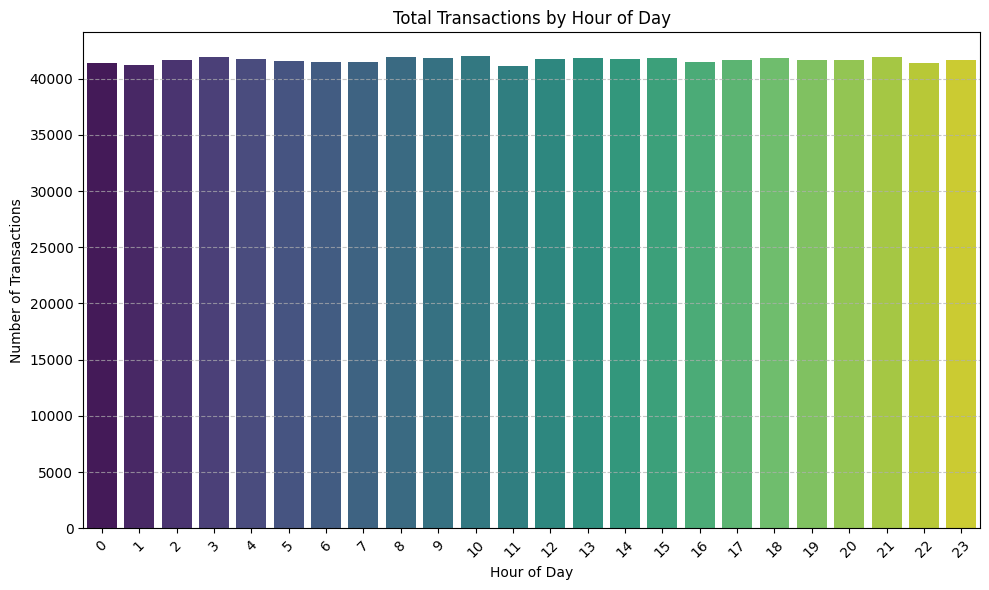

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=transactions_by_hour.index, y=transactions_by_hour.values, palette='viridis')
plt.title('Total Transactions by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous plot generated a `FutureWarning` because `palette` was used without assigning `hue`. To fix this and follow best practices, I will explicitly set `hue` to the x-axis variable and set `legend=False`.



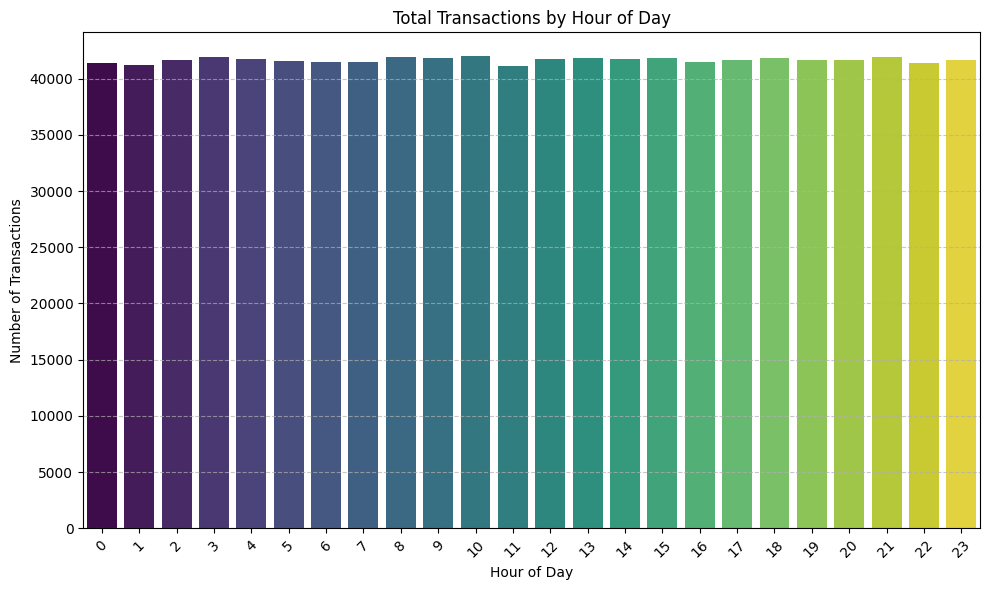

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=transactions_by_hour.index, y=transactions_by_hour.values, palette='viridis', hue=transactions_by_hour.index, legend=False)
plt.title('Total Transactions by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
To visualize the distribution of transactions by day of the week, I need to create a bar chart using the `transactions_by_day` data. This will help in easily identifying peak transaction days.



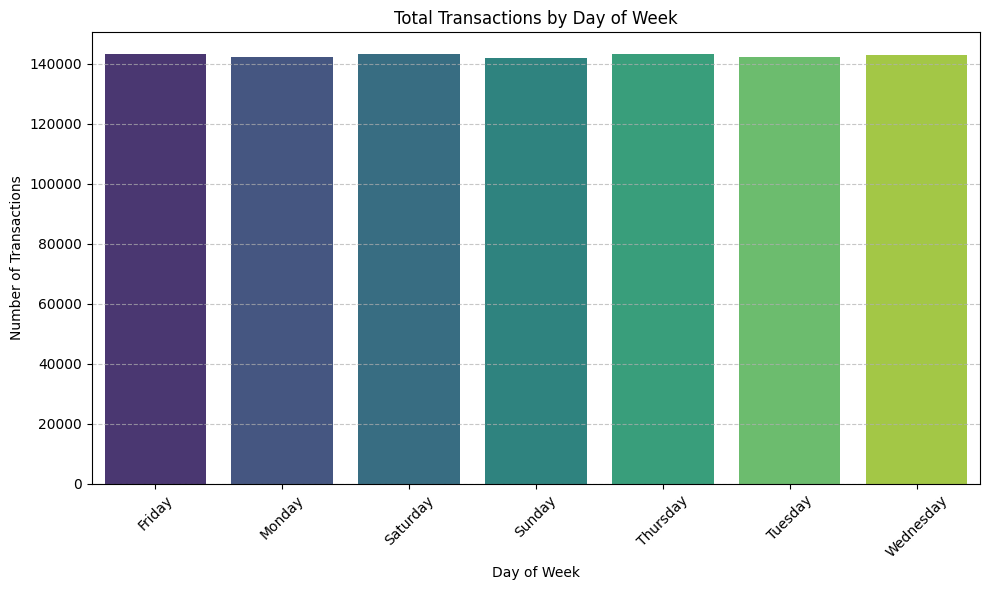

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=transactions_by_day.index, y=transactions_by_day.values, palette='viridis', hue=transactions_by_day.index, legend=False)
plt.title('Total Transactions by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()